In [52]:
import pandas as pd
import trxtools.methods as ttm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Load data

In [53]:
# Use files with multioverlap disabled (no -O option)

df00_uniq = pd.read_csv("../03a_FeatureCounts_umitools/featureCounts_umitools_uniq.list", sep="\t", skiprows=1)
df00_uniq = df00_uniq.drop(columns=['Chr', 'Start', 'End', 'Strand']).set_index('Geneid')
df00_uniq = ttm.cleanNames(df00_uniq, ['02c_alignment_all_umitools/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
df00_uniq = df00_uniq[['none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2', 'Length']]

df01_multi = pd.read_csv("../03a_FeatureCounts_umitools/featureCounts_umitools_multimappers.list", sep="\t", skiprows=1)
df01_multi = df01_multi.drop(columns=['Chr', 'Start', 'End', 'Strand']).set_index('Geneid')
df01_multi = ttm.cleanNames(df01_multi, ['02c_alignment_all_umitools/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
df01_multi = df01_multi[['none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2', 'Length']]

Load TPM tables

In [54]:
test_uniq_tpm = pd.read_csv("../03a_FeatureCounts_umitools/featureCounts_umitools_uniq_TPM.txt", sep="\t")
test_uniq_tpm = ttm.cleanNames(test_uniq_tpm, ['02c_alignment_all_umitools/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
test_uniq_tpm = test_uniq_tpm[['Geneid', 'none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2']].set_index('Geneid')

test_multi_tpm = pd.read_csv("../03a_FeatureCounts_umitools/featureCounts_umitools_multimappers_TPM.txt", sep="\t")
test_multi_tpm = ttm.cleanNames(test_multi_tpm, ['02c_alignment_all_umitools/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
test_multi_tpm = test_multi_tpm[['Geneid', 'none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2']].set_index('Geneid')

## Basic QC

### Number of mapped reads

In [55]:
summary_uniq_new = pd.read_csv("../03a_FeatureCounts_umitools/featureCounts_umitools_uniq.list.summary", sep="\t")
summary_uniq_new = ttm.cleanNames(summary_uniq_new, ['02c_alignment_all_umitools/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
summary_uniq_new = summary_uniq_new[['Status', 'none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2']]

summary_multi_new = pd.read_csv("../03a_FeatureCounts_umitools/featureCounts_umitools_multimappers.list.summary", sep="\t")
summary_multi_new = ttm.cleanNames(summary_multi_new, ['02c_alignment_all_umitools/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
summary_multi_new = summary_multi_new[['Status', 'none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2']]

/tmp/ipykernel_479/2895098545.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pd.DataFrame(summary_uniq_new.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])


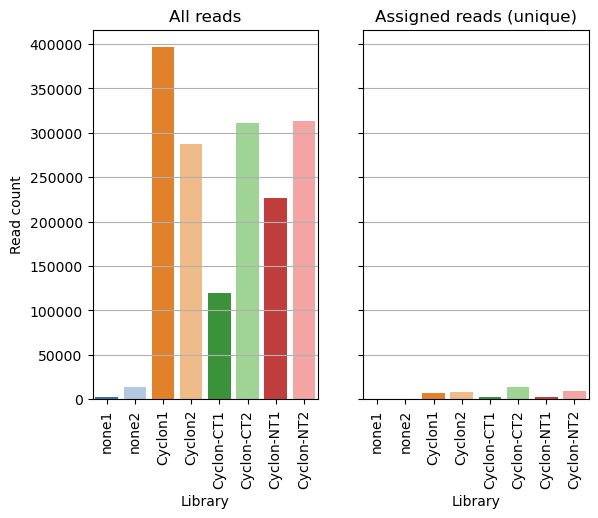

In [56]:
fig, axes = plt.subplots(1,2, sharey=True)
sns.barplot(pd.DataFrame(summary_uniq_new.sum()).T, palette='tab20', ax=axes[0])
sns.barplot(pd.DataFrame(summary_uniq_new.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])
# plt.title("Read count per library")
axes[0].set_ylabel("Read count")
axes[0].set_title("All reads")
axes[1].set_title("Assigned reads (unique)")
for ax in axes:
    ax.grid(axis='y')
    ax.set_xlabel("Library")
    ax.tick_params(axis='x', rotation=90)

/tmp/ipykernel_479/1923338170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pd.DataFrame(summary_multi_new.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])


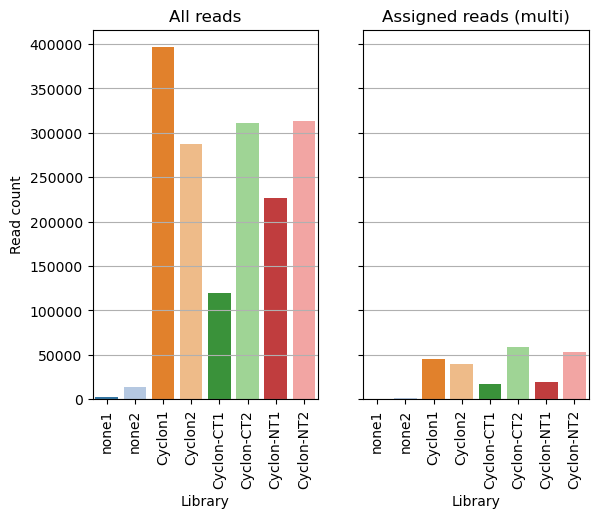

In [57]:
fig, axes = plt.subplots(1,2, sharey=True)
sns.barplot(pd.DataFrame(summary_multi_new.sum()).T, palette='tab20', ax=axes[0])
sns.barplot(pd.DataFrame(summary_multi_new.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])
# plt.title("Read count per library")
axes[0].set_ylabel("Read count")
axes[0].set_title("All reads")
axes[1].set_title("Assigned reads (multi)")
for ax in axes:
    ax.grid(axis='y')
    ax.set_xlabel("Library")
    ax.tick_params(axis='x', rotation=90)

### Sample correlations

Text(0.5, 1.0, 'Multimapping Reads Correlation (no overlap)')

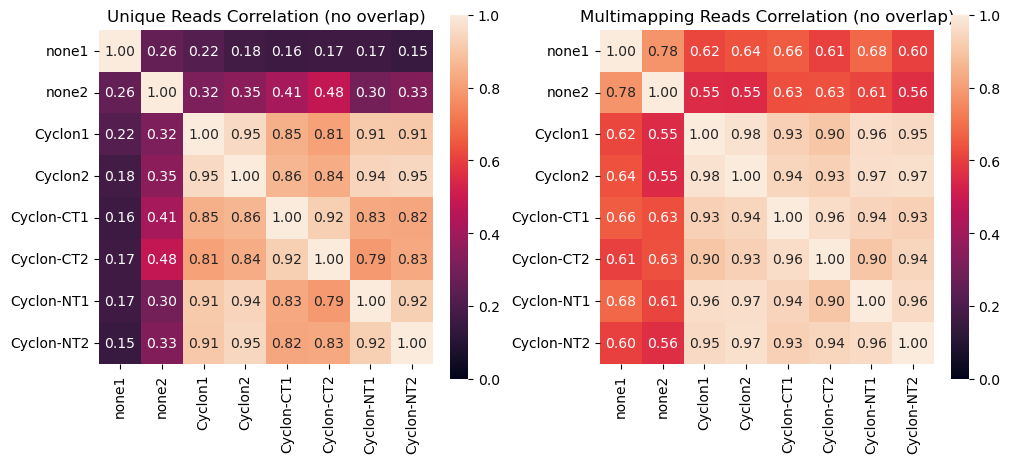

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

sns.heatmap(df00_uniq_tpm.corr('pearson'), annot=True, fmt=".2f", square=True, vmin=0, vmax=1, cbar_kws={"shrink": .8}, ax=axes[0])
axes[0].set_title("Unique Reads Correlation (no overlap)")

sns.heatmap(df01_multi_tpm.corr('pearson'), annot=True, fmt=".2f", square=True, vmin=0, vmax=1, cbar_kws={"shrink": .8}, ax=axes[1])
axes[1].set_title("Multimapping Reads Correlation (no overlap)")

## Read classes
Look at what kinds of loci reads map to

Get gene types from GTF file

In [59]:
gtf = pd.read_csv("hg41_annotation_gencode_tRNA_rRNA.gtf", sep="\t", header=None)
gtf = gtf[gtf[2].isin(['gene'])]
gtf_classes = gtf[8].str.split("; ", expand=True)[[0,1]]
gtf_classes[0] = gtf_classes[0].str.replace('gene_id "', '', regex=False)
gtf_classes[0] = gtf_classes[0].str.replace('"', '', regex=False)
gtf_classes[1] = gtf_classes[1].str.replace('gene_type "', '', regex=False)
gtf_classes[1] = gtf_classes[1].str.replace('"', '', regex=False)
gtf_classes = gtf_classes.rename(columns={0: 'gene_id', 1: 'gene_type'})
gtf_classes = gtf_classes.set_index('gene_id')
gtf_classes.head()

,gene_type
gene_id,
ENSG00000223972.5,transcribed_unprocessed_pseudogene
ENSG00000227232.5,unprocessed_pseudogene
ENSG00000278267.1,miRNA
ENSG00000243485.5,lncRNA
ENSG00000284332.1,miRNA


In [60]:
df00_uniq = pd.concat([df00_uniq, gtf_classes], axis=1)
df01_multi = pd.concat([df01_multi, gtf_classes], axis=1)

df00_uniq_tpm = pd.concat([df00_uniq_tpm, gtf_classes], axis=1)
df01_multi_tpm = pd.concat([df01_multi_tpm, gtf_classes], axis=1)

In [61]:
df00_uniq_tpm.to_csv("00_allsamples_featureCounts_TPM_geneclasses.csv")

Prepare df for plotting

In [62]:
# Calculate percentages for barplot
bar_uniq = df00_uniq.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1) # type: ignore
bar_multi = df01_multi.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)

bar_uniq_tpm = df00_uniq_tpm.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)
bar_multi_tpm = df01_multi_tpm.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)

#filter out some classes and sum them into 'other'
keep = [
    'Mt_rRNA', 'Mt_tRNA', 'lncRNA', 'miRNA',
    'polymorphic_pseudogene',
    'protein_coding', 'rRNA', 'rRNA_pseudogene',
    'snRNA', 'snoRNA', 'tRNA',
    'vaultRNA'
]

bar_uniq_keep = bar_uniq.loc[:,bar_uniq.columns.isin(keep)]
bar_uniq_keep['rRNA'] = bar_uniq_keep['rRNA'] + bar_uniq_keep['rRNA_pseudogene']
bar_uniq_keep = bar_uniq_keep.drop(columns=['rRNA_pseudogene'])
bar_uniq_plot = pd.concat([bar_uniq_keep, pd.DataFrame(bar_uniq.loc[:,~bar_uniq.columns.isin(keep)].sum(axis=1))], axis=1)
bar_uniq_plot = bar_uniq_plot.rename({0: 'other'}, axis=1)

bar_multi_keep = bar_multi.loc[:,bar_multi.columns.isin(keep)]
bar_multi_keep['rRNA'] = bar_multi_keep['rRNA'] + bar_multi_keep['rRNA_pseudogene']
bar_multi_keep = bar_multi_keep.drop(columns=['rRNA_pseudogene'])
bar_multi_plot = pd.concat([bar_multi_keep, pd.DataFrame(bar_multi.loc[:,~bar_multi.columns.isin(keep)].sum(axis=1))], axis=1)
bar_multi_plot = bar_multi_plot.rename({0: 'other'}, axis=1)

bar_uniq_tpm_keep = bar_uniq_tpm.loc[:,bar_uniq_tpm.columns.isin(keep)]
bar_uniq_tpm_keep['rRNA'] = bar_uniq_tpm_keep['rRNA'] + bar_uniq_tpm_keep['rRNA_pseudogene']
bar_uniq_tpm_keep = bar_uniq_tpm_keep.drop(columns=['rRNA_pseudogene'])
bar_uniq_tpm_plot = pd.concat([bar_uniq_tpm_keep, pd.DataFrame(bar_uniq_tpm.loc[:,~bar_uniq_tpm.columns.isin(keep)].sum(axis=1))], axis=1)
bar_uniq_tpm_plot = bar_uniq_tpm_plot.rename({0: 'other'}, axis=1)

bar_multi_tpm_keep = bar_multi_tpm.loc[:,bar_multi_tpm.columns.isin(keep)]
bar_multi_tpm_keep['rRNA'] = bar_multi_tpm_keep['rRNA'] + bar_multi_tpm_keep['rRNA_pseudogene']
bar_multi_tpm_keep = bar_multi_tpm_keep.drop(columns=['rRNA_pseudogene'])
bar_multi_tpm_plot = pd.concat([bar_multi_tpm_keep, pd.DataFrame(bar_multi_tpm.loc[:,~bar_multi_tpm.columns.isin(keep)].sum(axis=1))], axis=1)
bar_multi_tpm_plot = bar_multi_tpm_plot.rename({0: 'other'}, axis=1)

/tmp/ipykernel_479/4172869652.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_uniq_keep['rRNA'] = bar_uniq_keep['rRNA'] + bar_uniq_keep['rRNA_pseudogene']
/tmp/ipykernel_479/4172869652.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_multi_keep['rRNA'] = bar_multi_keep['rRNA'] + bar_multi_keep['rRNA_pseudogene']
/tmp/ipykernel_479/4172869652.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

Text(0.5, 0.98, 'Unique mapped reads - Gene classes')

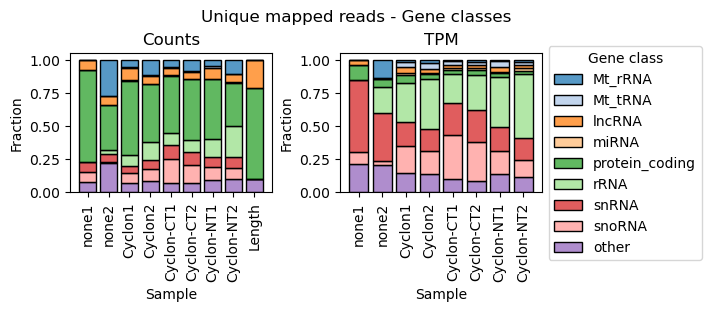

In [63]:
fig, axes = plt.subplots(1,2, figsize=(7, 3), layout='constrained')
sns.histplot(bar_uniq_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[0])
sns.histplot(bar_uniq_tpm_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[1])
axes[0].get_legend().remove()
legend = axes[1].get_legend()
legend.set_bbox_to_anchor((1, 1.1))
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Fraction')
    ax.set_xlabel('Sample')
axes[0].set_title("Counts")
axes[1].set_title("TPM")
plt.suptitle("Unique mapped reads - Gene classes")
# plt.savefig('00_read_classes_unique_comparison.png', dpi=300, bbox_inches='tight')

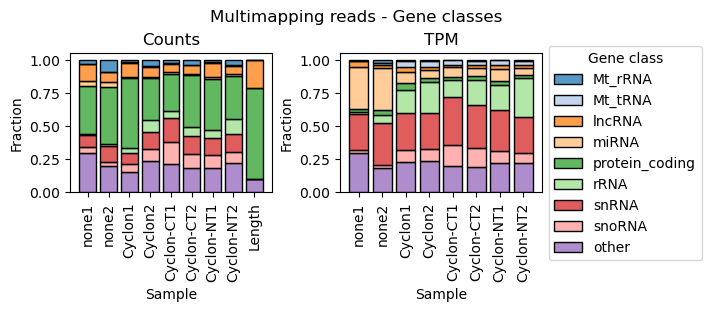

In [64]:
fig, axes = plt.subplots(1,2, figsize=(7, 3), layout='constrained')
sns.histplot(bar_multi_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[0])
sns.histplot(bar_multi_tpm_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[1])
axes[0].get_legend().remove()
legend = axes[1].get_legend()
legend.set_bbox_to_anchor((1, 1.1))
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Fraction')
    ax.set_xlabel('Sample')
axes[0].set_title("Counts")
axes[1].set_title("TPM")
plt.suptitle("Multimapping reads - Gene classes")
plt.savefig('00_read_classes_multi_comparison.png', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Gene classes - uniquely mapped reads [TPM]')

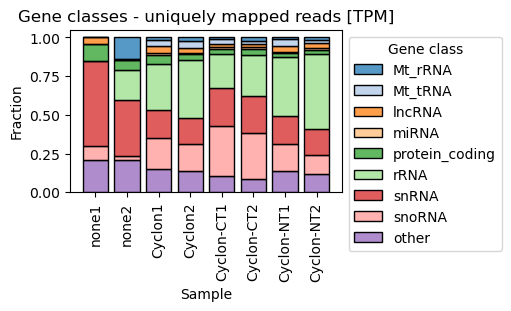

In [65]:
fig, ax = plt.subplots(figsize=(5, 3), layout='constrained')
sns.histplot(bar_uniq_tpm_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - uniquely mapped reads [TPM]")
# plt.savefig('00_read_classes_unique_TPMonly.png', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Gene classes - uniquely mapped reads [TPM]')

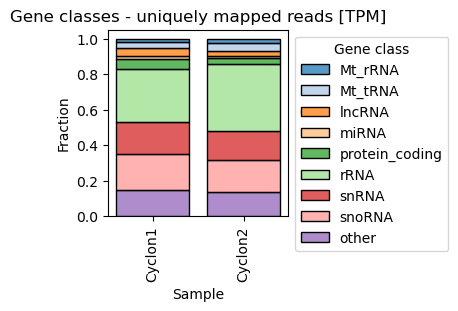

In [66]:
fig, ax = plt.subplots(figsize=(4, 3), layout='constrained')
sns.histplot(bar_uniq_tpm_plot.T[['Cyclon1', 'Cyclon2']].T.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - uniquely mapped reads [TPM]")
# plt.savefig('00_read_classes_unique_TPMonly_simple.png', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Gene classes - multimapping allowed [TPM]')

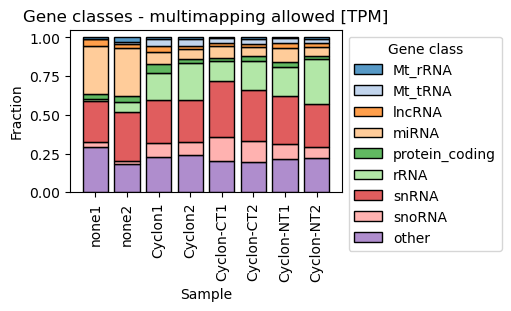

In [67]:
fig, ax = plt.subplots(figsize=(5, 3), layout='constrained')
sns.histplot(bar_multi_tpm_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - multimapping allowed [TPM]")
# plt.savefig('00_read_classes_multi_TPMonly.png', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Gene classes - multimapping allowed [TPM]')

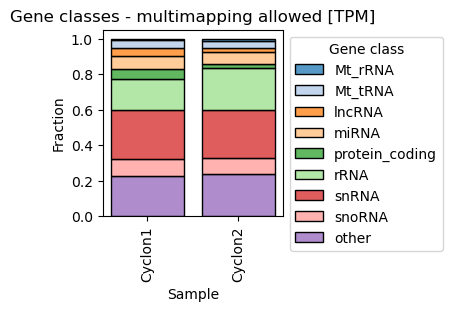

In [68]:
fig, ax = plt.subplots(figsize=(4, 3), layout='constrained')
sns.histplot(bar_multi_tpm_plot.T[['Cyclon1', 'Cyclon2']].T.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - multimapping allowed [TPM]")
# plt.savefig('00_read_classes_multi_TPMonly_simple.png', dpi=300, bbox_inches='tight')

### Top hits in selected classes

#### snRNA

In [71]:
df_top_snrna = df01_multi_tpm[df01_multi_tpm['gene_type'] == 'snRNA'].copy()
df_top_snrna['Cyclon_mean'] = df_top_snrna[['Cyclon1', 'Cyclon2']].mean(axis=1)
df_top_snrna = df_top_snrna.sort_values('Cyclon_mean', ascending=False)
# df_top_snrna.columns = df_top_snrna.columns[-1:].tolist() + df_top_snrna.columns[:-1].tolist()
df_top_snrna.head(15)

,none1,none2,Cyclon1,Cyclon2,Cyclon-CT1,Cyclon-CT2,Cyclon-NT1,Cyclon-NT2,gene_type,Cyclon_mean
ENSG00000273768.1,5366.454317,19804.321509,6690.529642,7391.358318,12319.334448,11695.309794,8751.747828,8563.619722,snRNA,7040.943980
ENSG00000207005.1,5366.454317,21784.753660,6690.529642,7362.709642,12388.544193,11695.309794,8882.370930,8699.910752,snRNA,7026.619642
ENSG00000206737.1,5366.454317,19804.321509,6690.529642,7334.060966,12250.124704,11487.854188,8817.059379,8563.619722,snRNA,7012.295304
ENSG00000206652.1,5366.454317,19804.321509,6690.529642,7334.060966,12457.753937,11721.241745,8882.370930,8722.625924,snRNA,7012.295304
ENSG00000207513.1,5366.454317,19804.321509,6551.143608,7248.114939,12388.544193,11617.513942,8947.682481,8609.050065,snRNA,6899.629274
ENSG00000207389.1,5366.454317,21784.753660,6551.143608,7190.817588,12319.334448,11384.126385,8882.370930,8586.334894,snRNA,6870.980598
ENSG00000206596.1,5366.454317,19804.321509,6411.757574,7305.412291,12319.334448,11565.650041,8882.370930,8359.183177,snRNA,6858.584932
ENSG00000206588.1,5366.454317,19804.321509,6411.757574,7305.412291,12319.334448,11539.718090,8882.370930,8381.898349,snRNA,6858.584932
ENSG00000277918.1,5366.454317,15843.457207,5261.822791,5471.897049,9481.734941,8687.203506,6661.778197,6133.096353,snRNA,5366.859920
ENSG00000206585.1,0.000000,7921.728604,3867.962449,4784.328834,6920.974409,7649.925475,4310.562363,5656.077747,snRNA,4326.145641


#### snoRNA

In [72]:
df_top_snorna = df00_uniq_tpm[df00_uniq_tpm['gene_type'] == 'snoRNA'].copy()
df_top_snorna['Cyclon_mean'] = df_top_snorna[['Cyclon1', 'Cyclon2']].mean(axis=1)
df_top_snorna = df_top_snorna.sort_values('Cyclon_mean', ascending=False)
# df_top_snorna.columns = df_top_snorna.columns[-1:].tolist() + df_top_snorna.columns[:-1].tolist()
df_top_snorna.head(5)

,none1,none2,Cyclon1,Cyclon2,Cyclon-CT1,Cyclon-CT2,Cyclon-NT1,Cyclon-NT2,gene_type,Cyclon_mean
ENSG00000200087.1,0.0,22642.120452,23884.902730,23694.263561,47579.239748,25950.810785,24020.037781,17351.099063,snoRNA,23789.583146
ENSG00000252213.1,0.0,0.000000,5590.083618,5917.564304,11658.056685,9982.429411,8688.098772,4513.027918,snoRNA,5753.823961
ENSG00000212607.1,0.0,0.000000,4649.351295,5490.764457,8962.846197,8499.338611,4007.705322,2580.564866,snoRNA,5070.057876
ENSG00000200959.1,0.0,0.000000,4161.763354,5521.823326,14231.913356,16975.999359,6186.979428,4419.006503,snoRNA,4841.793340
ENSG00000207523.1,0.0,0.000000,5118.193442,4542.885119,12947.830948,9635.156027,1973.719538,3438.850925,snoRNA,4830.539281


#### rRNA_pseudogene

In [75]:
df_top_pseudo = df00_uniq_tpm[df00_uniq_tpm['gene_type'] == 'rRNA_pseudogene'].copy()
df_top_pseudo['Cyclon_mean'] = df_top_pseudo[['Cyclon1', 'Cyclon2']].mean(axis=1)
df_top_pseudo = df_top_pseudo.sort_values('Cyclon_mean', ascending=False)
# df_top_snrna.columns = df_top_snrna.columns[-1:].tolist() + df_top_snrna.columns[:-1].tolist()
df_top_pseudo.head(5)

,none1,none2,Cyclon1,Cyclon2,Cyclon-CT1,Cyclon-CT2,Cyclon-NT1,Cyclon-NT2,gene_type,Cyclon_mean
ENSG00000201185.1,0.0,0.0,8731.035872,13539.579178,12497.772653,11651.384434,13235.531022,15540.791777,rRNA_pseudogene,11135.307525
ENSG00000199994.1,0.0,0.0,8598.564983,10587.950917,10019.267002,6554.433353,7700.137826,9863.222515,rRNA_pseudogene,9593.257950
ENSG00000252211.1,0.0,0.0,5732.376655,8516.395303,10645.471190,7394.745321,17500.313240,15749.339177,rRNA_pseudogene,7124.385979
ENSG00000201920.1,0.0,0.0,6361.866615,7797.911840,10241.657275,6479.040877,10631.031408,7247.996647,rRNA_pseudogene,7079.889227
ENSG00000201595.1,0.0,0.0,5768.811253,6583.333520,6633.518937,6765.223474,7415.386966,8763.114591,rRNA_pseudogene,6176.072386


In [76]:
bar_multi_tpm_plot

,Mt_rRNA,Mt_tRNA,lncRNA,miRNA,protein_coding,rRNA,snRNA,snoRNA,other
none1,0.012971,0.000000,0.040739,0.314990,0.028781,0.014411,0.266260,0.028446,0.293402
none2,0.028958,0.012286,0.025153,0.312417,0.036505,0.065209,0.314770,0.021622,0.183080
Cyclon1,0.008466,0.044964,0.042687,0.078206,0.055700,0.173571,0.276882,0.091982,0.227543
Cyclon2,0.011227,0.041905,0.021601,0.067355,0.022925,0.237844,0.271245,0.088659,0.237239
Cyclon-CT1,0.006418,0.031088,0.020055,0.075220,0.018725,0.128330,0.366517,0.152500,0.201147
Cyclon-CT2,0.009924,0.031088,0.022954,0.058196,0.031536,0.186906,0.325572,0.139977,0.193847
Cyclon-NT1,0.005399,0.033047,0.031380,0.091917,0.028704,0.189829,0.310466,0.091780,0.217479
Cyclon-NT2,0.008602,0.029986,0.020989,0.058364,0.022818,0.290026,0.274027,0.073124,0.222065


#### rRNA

In [77]:
tsdf = pd.concat([df00_uniq_tpm[df00_uniq_tpm['gene_type'] == 'rRNA_pseudogene'],
           df00_uniq_tpm[df00_uniq_tpm['gene_type'] == 'rRNA']])
tsdf['Cyclon_mean'] = tsdf[['Cyclon1', 'Cyclon2']].mean(axis=1)
tsdf = tsdf.sort_values('Cyclon_mean', ascending=False)
# tsdf = tsdf.drop(columns=['gene_type']).apply(lambda x: x/sum(x), axis=1)
tsdf

,none1,none2,Cyclon1,Cyclon2,Cyclon-CT1,Cyclon-CT2,Cyclon-NT1,Cyclon-NT2,gene_type,Cyclon_mean
ENSG00000201321.1,0.0,0.0,16257.790934,22968.928963,19075.547733,16241.323757,28676.983881,26569.740781,rRNA,19613.359948
ENSG00000201185.1,0.0,0.0,8731.035872,13539.579178,12497.772653,11651.384434,13235.531022,15540.791777,rRNA_pseudogene,11135.307525
ENSG00000199994.1,0.0,0.0,8598.564983,10587.950917,10019.267002,6554.433353,7700.137826,9863.222515,rRNA_pseudogene,9593.257950
ENSG00000252211.1,0.0,0.0,5732.376655,8516.395303,10645.471190,7394.745321,17500.313240,15749.339177,rRNA_pseudogene,7124.385979
ENSG00000201920.1,0.0,0.0,6361.866615,7797.911840,10241.657275,6479.040877,10631.031408,7247.996647,rRNA_pseudogene,7079.889227
...,...,...,...,...,...,...,...,...,...,...
ENSG00000251997.1,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,rRNA_pseudogene,0.000000
ENSG00000200527.1,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,160.367171,rRNA_pseudogene,0.000000
ENSG00000200872.1,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,rRNA_pseudogene,0.000000
ENSG00000202060.1,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,rRNA_pseudogene,0.000000


In [78]:
tsdf = pd.concat([df01_multi_tpm[df01_multi_tpm['gene_type'] == 'rRNA_pseudogene'],
           df01_multi_tpm[df01_multi_tpm['gene_type'] == 'rRNA']])
tsdf['Cyclon_mean'] = tsdf[['Cyclon1', 'Cyclon2']].mean(axis=1)
tsdf = tsdf.sort_values('Cyclon_mean', ascending=False)
# tsdf = tsdf.drop(columns=['gene_type']).apply(lambda x: x/sum(x), axis=1)
tsdf

,none1,none2,Cyclon1,Cyclon2,Cyclon-CT1,Cyclon-CT2,Cyclon-NT1,Cyclon-NT2,gene_type,Cyclon_mean
ENSG00000277739.1,5752.27783,6368.448485,8366.806132,8966.848232,11053.655599,7310.437257,7910.808250,6403.599900,rRNA,8666.827182
ENSG00000201321.1,0.00000,0.000000,2689.330542,3790.292012,2956.826378,3395.124310,3780.386244,5040.095739,rRNA,3239.811277
ENSG00000201413.1,0.00000,2706.590606,2714.543016,2740.723304,1891.733005,3295.950942,1963.700632,3352.759339,rRNA_pseudogene,2727.633160
ENSG00000199994.1,0.00000,2598.326982,2103.056484,3270.074433,1816.063685,3674.453695,1542.397587,3427.265103,rRNA_pseudogene,2686.565459
ENSG00000201185.1,0.00000,0.000000,2257.116705,2842.719009,2384.537402,3180.695406,2160.220711,3913.117810,rRNA_pseudogene,2549.917857
...,...,...,...,...,...,...,...,...,...,...
ENSG00000251850.1,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,rRNA_pseudogene,0.000000
ENSG00000222251.1,0.00000,0.000000,0.000000,0.000000,0.000000,31.042627,0.000000,54.383769,rRNA_pseudogene,0.000000
ENSG00000199395.1,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,rRNA_pseudogene,0.000000
ENSG00000252246.1,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,rRNA_pseudogene,0.000000
